# 4.3 Visualizing Text Data Lab

## Dataset
For this lab, I used the **yelp_subset.csv** dataset. This dataset is appropriate for a text visualization lab because it contains written customer reviews in the `text` column, review scores in the `stars` column, and business categories in the `categories` column. That makes it possible to explore both the language customers use and how that language changes across different kinds of reviews.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

df = pd.read_csv('../../Lab/yelp_subset.csv')
df.head()


,review_id,user_id,business_id,date,text,useful,funny,cool,name,neighborhood,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,categories
0,zsbVXbCsycrTWkVlsKsVOg,u3NDqJr25UwYeXZypxJcqw,xBkXnzbctPGWG86L27GNFQ,2015-01-03,We brought our Doxie to Dr. Scholten for serio...,0,0,1,"""Hopi Animal Hospital""",NaN,"""5533 E Bell Rd, Ste 101""",Scottsdale,AZ,85254,33.639916,-111.961780,4.5,30,1,Pet Services;Pet Sitting;Pets;Veterinarians
1,d3iCvvJsJZs4U-ZFfq_pSA,DxHP0hTWS9Jpd-xSVCMYAg,JDjOobEd_Tm6Z06YRmWkbg,2008-05-13,"First, I'm a regular here. Sunday afternoons a...",5,3,5,"""Charlie's""",NaN,"""727 W Camelback Rd""",Phoenix,AZ,85013,33.508967,-112.083610,3.0,158,1,Bars;Nightlife;Dance Clubs;Gay Bars
2,yTS2FOyhmRHgwAXSG8muiQ,-aYO8Ga4U5hrwxV7y1IaiA,qiRyyRWt6jmAxcoVW0-WHA,2015-08-02,"Best AYCE in Mississauga. For an AYCE, their s...",6,0,1,"""Heart Sushi""",East Credit,"""815 Britannia Road W, Unit 2""",Mississauga,ON,L5V 2X8,43.610533,-79.698421,3.5,278,1,Chinese;Japanese;Buffets;Restaurants;Sushi Bars
3,W1PG83hPCogZdLlstltWZw,EJLsnsI53YKBHq9te2KSiQ,t67GMPZ0cv_ItKlID-JFiQ,2013-04-10,"Love it! It's a nice quick, inexpensive & tast...",0,1,0,"""Banzo""",NaN,"""2105 Sherman Ave""",Madison,WI,53704,43.101672,-89.364595,4.5,286,1,Food;Mediterranean;Food Trucks;Restaurants
4,Q8IuYiUzeK-Uc8mK-luL3w,gknq0IAq9jaSlotJ465FGw,6P-JmU0VW-qhYq7It1wowg,2014-11-10,Dont eat here! Doesnt even taste like pho here...,0,0,0,"""Pho 68""",NaN,"""2025 N Dobson Rd""",Chandler,AZ,85224,33.336151,-111.874338,3.5,77,0,Vietnamese;Restaurants


## Prepare the text data

I focused on **Mexican** businesses because the category had enough reviews to support multiple meaningful text visualizations.


In [2]:

mexican_df = df[df['categories'].fillna('').str.contains('Mexican', case=False, na=False)].copy()

high_reviews = mexican_df[mexican_df['stars'] >= 4]['text'].dropna()
low_reviews = mexican_df[mexican_df['stars'] <= 3]['text'].dropna()

print("Mexican review count:", len(mexican_df))
print("Higher-rated reviews (4-5 stars):", len(high_reviews))
print("Lower-rated reviews (3 stars or below):", len(low_reviews))


Mexican review count: 109
Higher-rated reviews (4-5 stars): 60
Lower-rated reviews (3 stars or below): 25


## Visualization 1: Word cloud of Mexican business reviews

This word cloud summarizes the most common words that appear across reviews for Mexican businesses in the dataset.


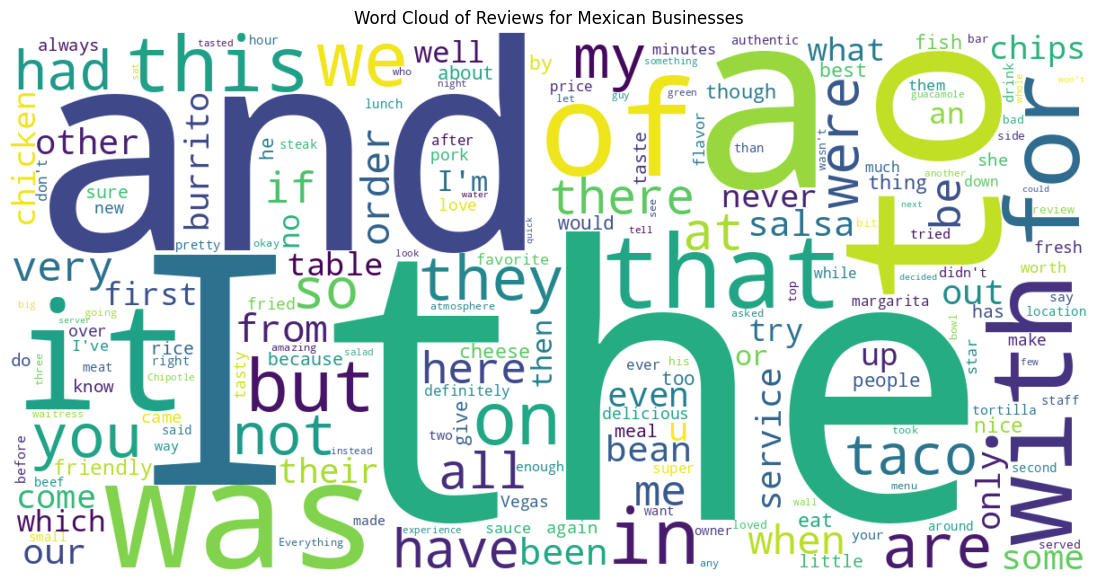

In [3]:

all_text = " ".join(mexican_df['text'].dropna())

extra_stopwords = {
    'food','place','really','just','got','one','also','back','will','can','ve','don','did',
    'still','went','time','get','like','good','great','restaurant','mexican','go','ordered'
}

wc = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    stopwords=extra_stopwords,
    collocations=False
).generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Reviews for Mexican Businesses')
plt.show()


**Interpretation:** The word cloud shows that customers often talk about service, salsa, tacos, burritos, chicken, and staff when reviewing Mexican businesses. This suggests that both food items and the overall service experience are central themes in these reviews, rather than people only discussing the restaurant in a general way.


## Visualization 2: Most common words in higher-rated Mexican reviews

Next, I looked only at reviews with **4 stars or higher** to see what language appears most often in stronger reviews.


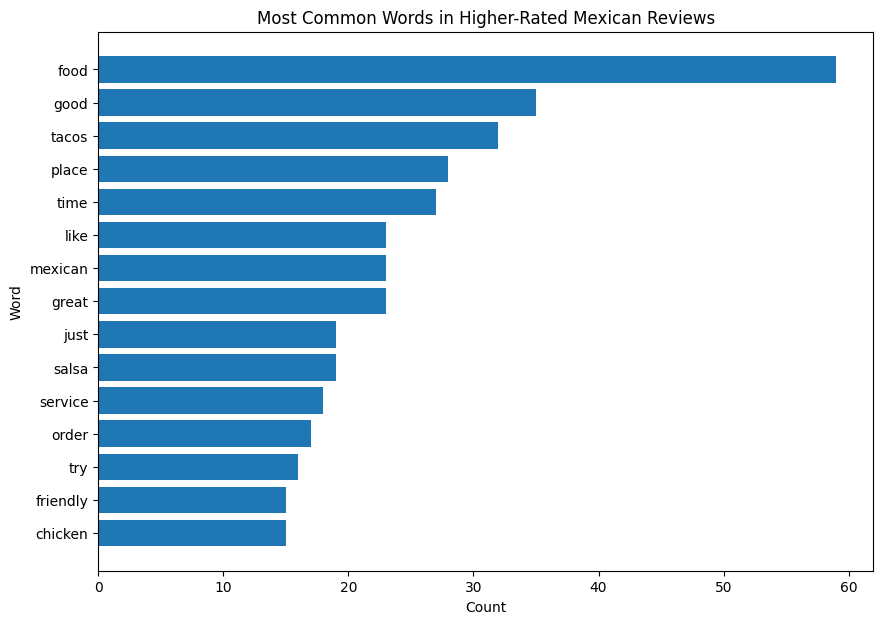

,word,count
1,food,59
3,good,35
12,tacos,32
9,place,28
13,time,27
6,like,23
4,great,23
7,mexican,23
5,just,19
10,salsa,19


In [4]:

vectorizer_high = CountVectorizer(stop_words='english', max_features=15)
X_high = vectorizer_high.fit_transform(high_reviews)

high_counts = pd.DataFrame({
    'word': vectorizer_high.get_feature_names_out(),
    'count': np.asarray(X_high.sum(axis=0)).ravel()
}).sort_values('count', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(high_counts['word'], high_counts['count'])
plt.title('Most Common Words in Higher-Rated Mexican Reviews')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

high_counts.sort_values('count', ascending=False)


**Interpretation:** In the higher-rated reviews, positive dining words such as *best, delicious, friendly, fresh, love,* and *staff* appear frequently. That pattern suggests that strong reviews are tied not only to food quality, but also to friendliness, freshness, and a satisfying overall customer experience.


## Visualization 3: Most common words in lower-rated Mexican reviews

Finally, I looked at reviews with **3 stars or below** to compare the language used in weaker reviews.


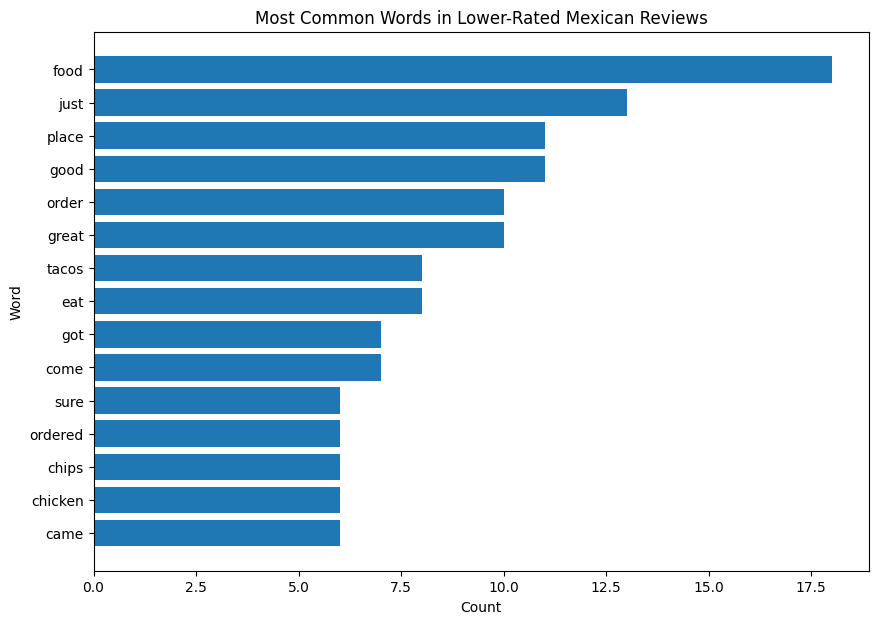

,word,count
5,food,18
9,just,13
6,good,11
12,place,11
8,great,10
10,order,10
4,eat,8
14,tacos,8
7,got,7
3,come,7


In [5]:

vectorizer_low = CountVectorizer(stop_words='english', max_features=15)
X_low = vectorizer_low.fit_transform(low_reviews)

low_counts = pd.DataFrame({
    'word': vectorizer_low.get_feature_names_out(),
    'count': np.asarray(X_low.sum(axis=0)).ravel()
}).sort_values('count', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(low_counts['word'], low_counts['count'])
plt.title('Most Common Words in Lower-Rated Mexican Reviews')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

low_counts.sort_values('count', ascending=False)


**Interpretation:** The lower-rated reviews still mention food items, but they also include more complaint-oriented words such as *order, service, asked,* and *cheese,* often pointing to mistakes, missing items, or disappointing service. Compared with the higher-rated reviews, the weaker reviews focus less on enjoyment and more on problems with how the meal or service was handled.


## Conclusion

These three visualizations show that text data can reveal more than just whether customers liked a business. For Mexican businesses in this dataset, the language in stronger reviews centers on freshness, flavor, and friendly staff, while weaker reviews more often reflect ordering issues and service frustrations.
